## Ejercicio de Análisis: Diagnóstico de Cáncer de Mama
Contexto: El archivo breast_cancer_data.csv contiene mediciones obtenidas de imágenes digitalizadas de una punción aspirativa con aguja fina (PAAF) de una masa mamaria. La columna target indica si la masa es maligna (0) o benigna (1).

Preguntas del Ejercicio:
1. Carga e Inspección: Carga el archivo y muestra las primeras 6 filas para entender la estructura de las columnas.

2. Dimensiones: ¿Cuántas observaciones (filas) y variables (columnas) tiene el conjunto de datos?

3. Tendencia Central: Calcula la media, la mediana y la desviación estándar de la columna mean radius.

4. Balance de Clases: ¿Cuántos registros corresponden a tumores benignos (1) y cuántos a malignos (0)?

5. Filtrado: Crea un nuevo subconjunto de datos que solo contenga los registros donde el mean area sea mayor a 1000.

6. Correlación: Calcula la correlación entre mean radius y mean perimeter. ¿Qué tipo de relación observas?

7. Visualización de Distribución: Genera un histograma del mean texture utilizando un color diferente para cada categoría de la columna target.

8. Transformación (Feature Engineering): Crea una nueva columna llamada compactness_ratio que sea el resultado de dividir mean compactness entre mean smoothness.

9. Agregación: Calcula el valor máximo de mean concavity para cada grupo de la variable target.

In [1]:
# Preparación: Carga de librería
library(tidyverse)

# 1. Carga e Inspección
# Nota: Asegúrate de que el archivo esté en tu directorio de trabajo
df <- read_csv("../../data/breast_cancer_data.csv")
head(df)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors
Rows: 569 Columns: 31
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
dbl (31): mean radius, mean texture, mean perimeter, mean area, mean smoothness, mean compactness, 

# A tibble: 6 × 31
  `mean radius` `mean texture` `mean perimeter` `mean area` `mean smoothness` `mean compactness` `mean concavity` `mean concave points` `mean symmetry`
          <dbl>          <dbl>            <dbl>       <dbl>             <dbl>              <dbl>            <dbl>                 <dbl>           <dbl>
1          18.0           10.4            123.        1001             0.118              0.278            0.300                 0.147            0.242
2          20.6           17.8            133.        1326             0.0847             0.0786           0.0869                0.0702           0.181
3          19.7           21.2            130         1203             0.110              0.160            0.197                 0.128            0.207
4          11.4           20.4             77.6        386.            0.142              0.284            0.241                 0.105            0.260
5          20.3           14.3            135.        1297           

In [2]:
# 2. Dimensiones
dimensiones <- dim(df)
print(paste("Filas:", dimensiones[1], "| Columnas:", dimensiones[2]))

[1] "Filas: 569 | Columnas: 31"


In [10]:
# 3. Tendencia Central (mean radius)
df %>%
  summarise(
    Media = mean(`mean radius`, na.rm = TRUE),
    Mediana = median(`mean radius`, na.rm = TRUE),
    Desviacion = sd(`mean radius`, na.rm = TRUE)
  )

# A tibble: 1 × 3
  Media Mediana Desviacion
  <dbl>   <dbl>      <dbl>
1  14.1    13.4       3.52

In [4]:
# 4. Balance de Clases
df %>%
  count(target) %>%
  mutate(descripcion = if_else(target == 1, "Benigno", "Maligno"))

# A tibble: 2 × 3
  target     n descripcion
   <dbl> <int> <chr>      
1      0   212 Maligno    
2      1   357 Benigno    

In [5]:
# 5. Filtrado (mean area > 1000)
df_grandes <- df %>%
  filter(`mean area` > 1000)

print(paste("Casos con área > 1000:", nrow(df_grandes)))

[1] "Casos con área > 1000: 92"


In [6]:
# 6. Correlación
correlacion <- cor(df$`mean radius`, df$`mean perimeter`)
print(paste("Correlación entre radio y perímetro:", round(correlacion, 4)))

[1] "Correlación entre radio y perímetro: 0.9979"


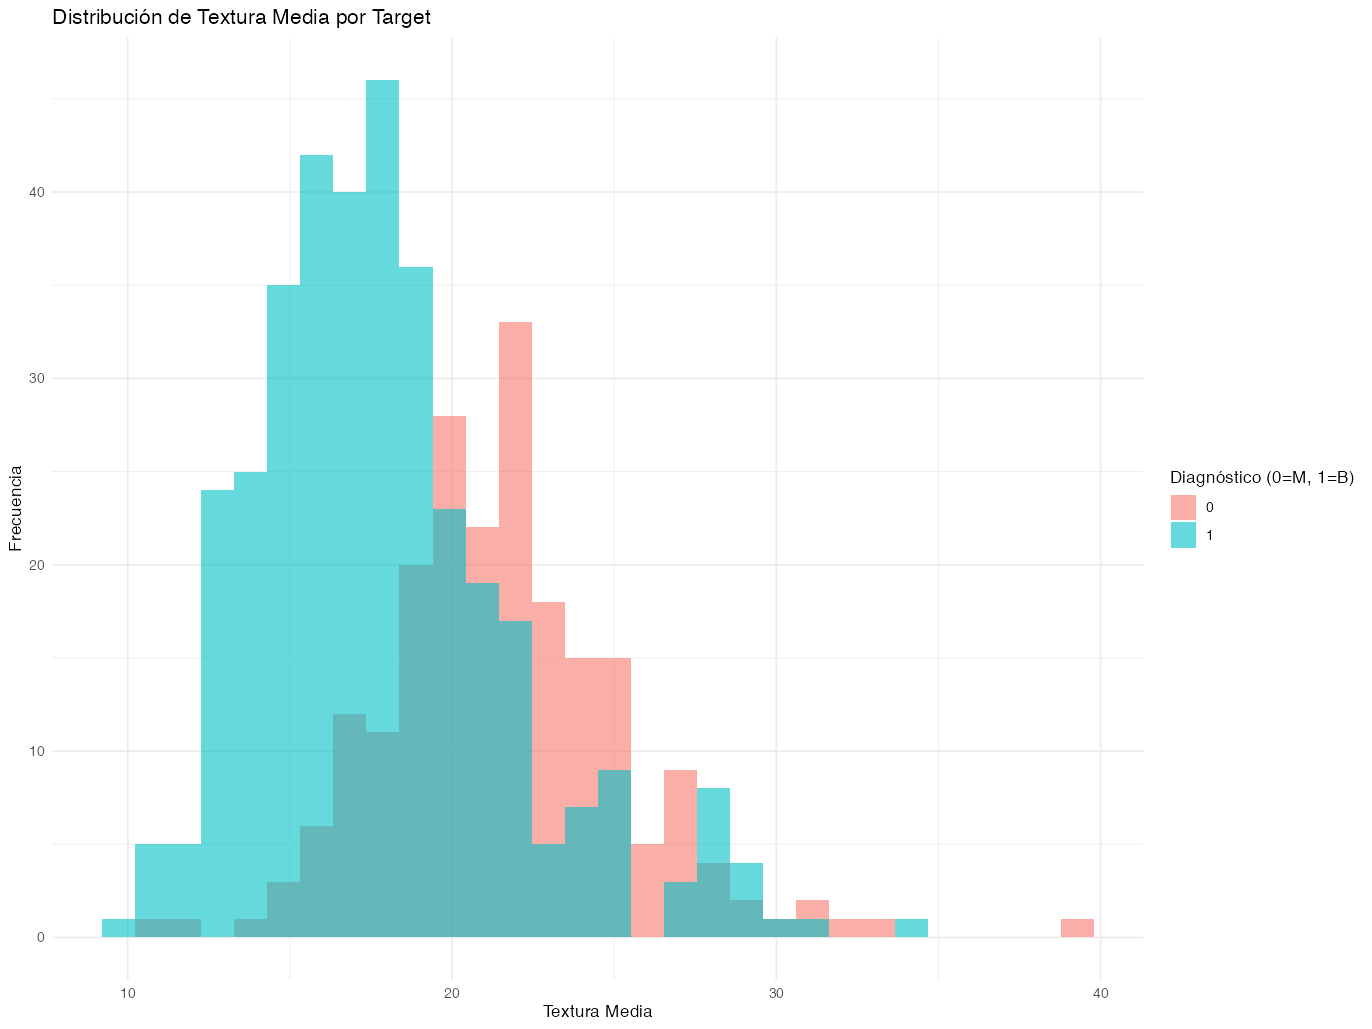

In [7]:
# 7. Visualización de Distribución (mean texture)
ggplot(df, aes(x = `mean texture`, fill = as.factor(target))) +
  geom_histogram(alpha = 0.6, bins = 30, position = "identity") +
  labs(
    title = "Distribución de Textura Media por Target",
    x = "Textura Media",
    y = "Frecuencia",
    fill = "Diagnóstico (0=M, 1=B)"
  ) +
  theme_minimal()

In [8]:
# 8. Transformación (creación de nueva columna)
df <- df %>%
  mutate(compactness_ratio = `mean compactness` / `mean smoothness`)

# Ver las primeras filas de la nueva columna
df %>% select(target, compactness_ratio) %>% head()

# A tibble: 6 × 2
  target compactness_ratio
   <dbl>             <dbl>
1      0             2.34 
2      0             0.928
3      0             1.46 
4      0             1.99 
5      0             1.32 
6      0             1.33 

In [9]:
# 9. Agregación (Máximo de mean concavity por target)
df %>%
  group_by(target) %>%
  summarise(max_concavity = max(`mean concavity`, na.rm = TRUE))

# A tibble: 2 × 2
  target max_concavity
   <dbl>         <dbl>
1      0         0.427
2      1         0.411